# Combinatorial CoWork 2026 — Notebook 01: Presentations to encodings

Audience:
- Participants who want to see the same mathematical motif appear through several source-object families.

Learning goals:
- Compare `SyntheticBoxFringe`, `PLFringe`, and `Flange` as source presentations.
- Confirm that `encode(...)` is the canonical workflow entrypoint regardless of synthetic provenance.
- Inspect the resulting encodings through summaries, accessors, and region/rank visuals.


In [1]:
NOTEBOOK_STEM = "01_presentations_to_encodings"

_TO_ROOT = let
    dir = abspath(pwd())
    root = nothing
    while true
        if isfile(joinpath(dir, "Project.toml")) && isfile(joinpath(dir, "src", "TamerOp.jl"))
            root = dir
            break
        end
        parent = dirname(dir)
        parent == dir && error("Could not locate repo root containing Project.toml and src/TamerOp.jl from pwd()=$(pwd()).")
        dir = parent
    end
    root
end

import Pkg
Pkg.activate(_TO_ROOT; io=devnull)

if !isdefined(Main, :TamerOp)
    @eval Main using TamerOp
end

TO = Main.TamerOp


TamerOp

## 1. Build four tiny source objects with the same broad geometric theme

We deliberately reuse interval/rectangle-style data so the only moving part is the source-object family, not the underlying mathematical picture.


In [2]:
SD = TO.SyntheticData

box_diag = SD.box_bar_fringe(
    bars=[([0.0, 0.0], [1.0, 1.0]), ([1.5, 0.25], [2.5, 1.25])]
)

box_coupled = SD.staircase_box_fringe(
    bars=[([0.0, 0.0], [1.75, 1.0]), ([0.75, 0.5], [2.5, 2.0]), ([1.5, 1.0], [3.5, 2.75])]
)

pl_diag = SD.pl_box_fringe(
    bars=[([0.0, 0.0], [1.0, 1.0]), ([1.0, 0.5], [2.25, 1.75])]
)

flange_rect = SD.orthant_bar_flange(
    bars=[([0, 0], [2, 2]), ([1, 1], [3, 3])],
)


Flange
  ambient_dim = 2
  field = TamerOp.CoreModules.CoeffFields.QQField
  nflats = 2
  ninjectives = 2
  matrix_size = (2, 2)


The first comparison step is still `describe(...)`. The point here is not yet to compute anything new; it is to see that the four sources live at different mathematical layers.

- `box_diag` and `box_coupled` are box-fringe presentations in ambient coordinates.
- `pl_diag` is a more general PL-fringe presentation.
- `flange_rect` is already a flange-style algebraic presentation on `Z^2`.

In these summaries, `matrix_size` means the size of the source object's defining coefficient or presentation matrix. It is a source-level summary field, not a separate universal matrix notion.


In [3]:
(; box_diag=TO.describe(box_diag),
   box_coupled=TO.describe(box_coupled),
   pl_diag=TO.describe(pl_diag),
   flange_rect=TO.describe(flange_rect))


(box_diag = (kind = :synthetic_box_fringe, ambient_dim = 2, nupsets = 2, ndownsets = 2, matrix_size = (2, 2), field = TamerOp.CoreModules.CoeffFields.QQField()), box_coupled = (kind = :synthetic_box_fringe, ambient_dim = 2, nupsets = 3, ndownsets = 3, matrix_size = (3, 3), field = TamerOp.CoreModules.CoeffFields.QQField()), pl_diag = (kind = :pl_fringe, ambient_dim = 2, nupsets = 2, ndownsets = 2, field = TamerOp.CoreModules.CoeffFields.QQField(), matrix_size = (2, 2)), flange_rect = (kind = :flange, ambient_dim = 2, field = "TamerOp.CoreModules.CoeffFields.QQField", nflats = 2, ninjectives = 2, matrix_size = (2, 2)))

## 2. Encode each source object through the same workflow surface

The normalization step is `encode(...)`. This is the key didactic point of the notebook: the provenance of the source object changes the source summary, but it should not change the notebook-facing answer to the question “turn this into an encoding I can compute with.”


In [4]:
enc_box_diag = TO.encode(box_diag)
enc_box_coupled = TO.encode(box_coupled)
enc_pl_diag = TO.encode(pl_diag)
enc_flange_rect = TO.encode(flange_rect)


EncodingResult
  poset_type: TamerOp.ZnEncoding.SignaturePoset{1, 1}
  module_type: TamerOp.Modules.PModule{Rational{BigInt}, TamerOp.CoreModules.CoeffFields.QQField, Matrix{Rational{BigInt}}, TamerOp.ZnEncoding.SignaturePoset{1, 1}}
  encoding_map_type: TamerOp.EncodingCore.CompiledEncoding{TamerOp.ZnEncoding.ZnEncodingMap{2, 1, 1}, TamerOp.ZnEncoding.SignaturePoset{1, 1}, Tuple{Vector{Int64}, Vector{Int64}}, Vector{Tuple{Int64, Int64}}, TamerOp.CoreModules.EncodingCache}
  backend: zn
  compiled: true
  has_cohomology: true
  has_presentation: true
  module_dims: [0, 0, 0, 0, 0, 1, 2, 1, 0]

All four outputs are now `EncodingResult`s. This is the workflow-level unification we want participants to internalize.

At this stage, `describe(...)` should look structurally similar across the four objects. The differences now come from the encoded geometry and the downstream module, not from having four unrelated workflow wrappers.


In [5]:
(; box_diag=TO.describe(enc_box_diag),
   box_coupled=TO.describe(enc_box_coupled),
   pl_diag=TO.describe(enc_pl_diag),
   flange_rect=TO.describe(enc_flange_rect))


(box_diag = (kind = :encoding_result, poset_type = TamerOp.ZnEncoding.SignaturePoset{1, 1}, module_type = TamerOp.Modules.PModule{Rational{BigInt}, TamerOp.CoreModules.CoeffFields.QQField, Matrix{Rational{BigInt}}, TamerOp.ZnEncoding.SignaturePoset{1, 1}}, encoding_map_type = TamerOp.EncodingCore.CompiledEncoding{TamerOp.PLBackend.PLEncodingMapBoxes{2, 1, 1}, TamerOp.ZnEncoding.SignaturePoset{1, 1}, Tuple{Vector{Float64}, Vector{Float64}}, Vector{Tuple{Float64, Float64}}, TamerOp.CoreModules.EncodingCache}, compiled = true, backend = :pl_backend, has_cohomology = true, has_presentation = true, module_dims = [0, 0, 0, 1, 0, 0, 1, 0]), box_coupled = (kind = :encoding_result, poset_type = TamerOp.ZnEncoding.SignaturePoset{1, 1}, module_type = TamerOp.Modules.PModule{Rational{BigInt}, TamerOp.CoreModules.CoeffFields.QQField, Matrix{Rational{BigInt}}, TamerOp.ZnEncoding.SignaturePoset{1, 1}}, encoding_map_type = TamerOp.EncodingCore.CompiledEncoding{TamerOp.PLBackend.PLEncodingMapBoxes{2, 1

Before rendering anything, inspect the encoding maps semantically. The encoding map `pi = encoding_map(enc)` is the region/classifier object attached to the encoding.

Here `encoding_axes(pi)` means the coordinate axes of the encoded parameter plane. `available_visuals(pi)` tells us which geometry-side views the notebook can ask for without touching internal fields.


In [6]:
pi_box = TO.encoding_map(enc_box_diag)
pi_flange = TO.encoding_map(enc_flange_rect)

(; box_axes=TO.encoding_axes(pi_box),
   box_visuals=TO.available_visuals(pi_box),
   flange_axes=TO.encoding_axes(pi_flange),
   flange_visuals=TO.available_visuals(pi_flange))


(box_axes = ([0.0, 1.0, 1.5, 2.5], [0.0, 0.25, 1.0, 1.25]), box_visuals = (:regions, :region_labels, :query_overlay), flange_axes = ([-1, 0, 1, 3, 4], [-1, 0, 1, 3, 4]), flange_visuals = (:regions, :region_labels, :query_overlay))

## 3. Visualize the four encodings directly

Now we keep the query fixed and vary only the object. For three of the four encodings, the public visual surface can render `kind=:regions` directly from the encoding map.

The PL encoding is the one exception at the moment: its compiled map does not currently register a direct `:regions` view on the public surface. So the fourth cell below is an explicit summary fallback rather than a rendered figure. That is still useful notebook information, and it keeps the limitation visible instead of hiding it.


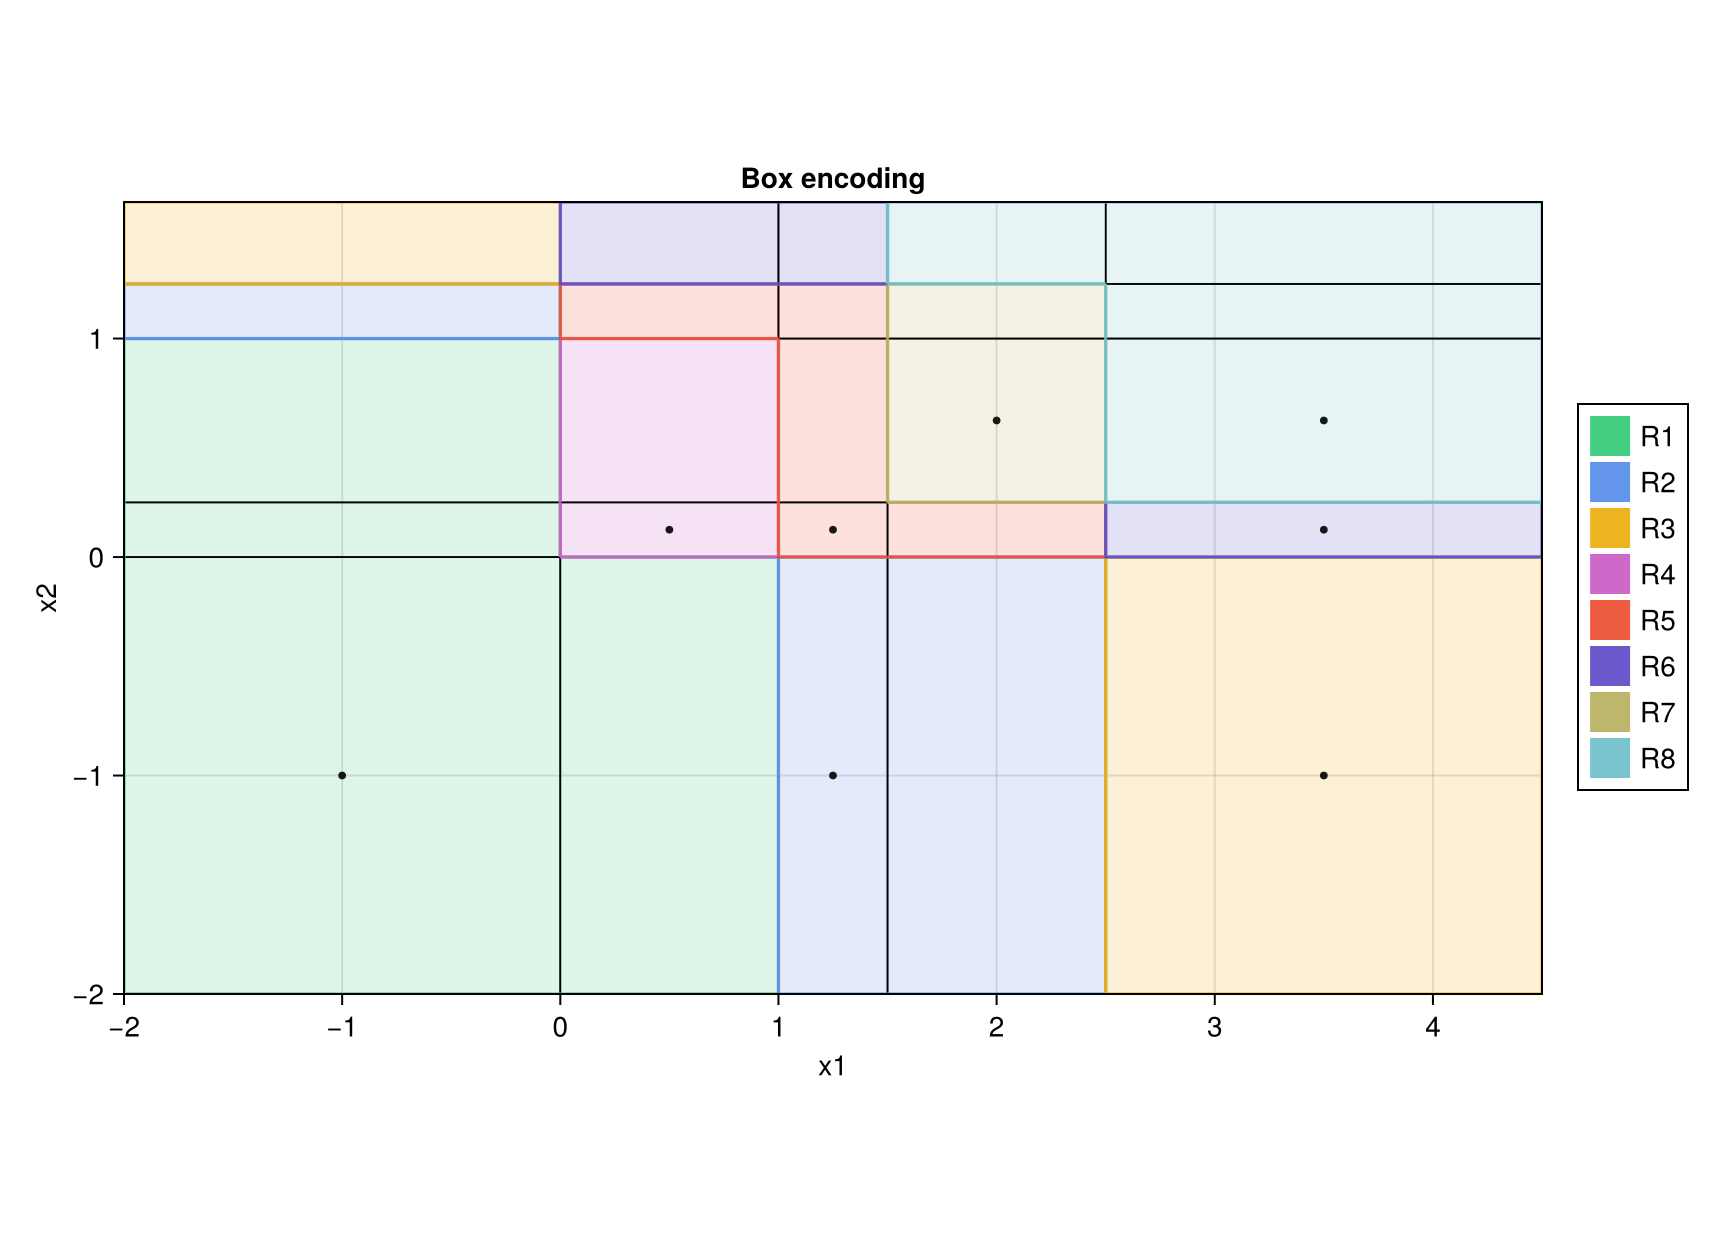

In [7]:
TO.visualize(TO.encoding_map(enc_box_diag); kind=:regions, backend=:cairomakie)


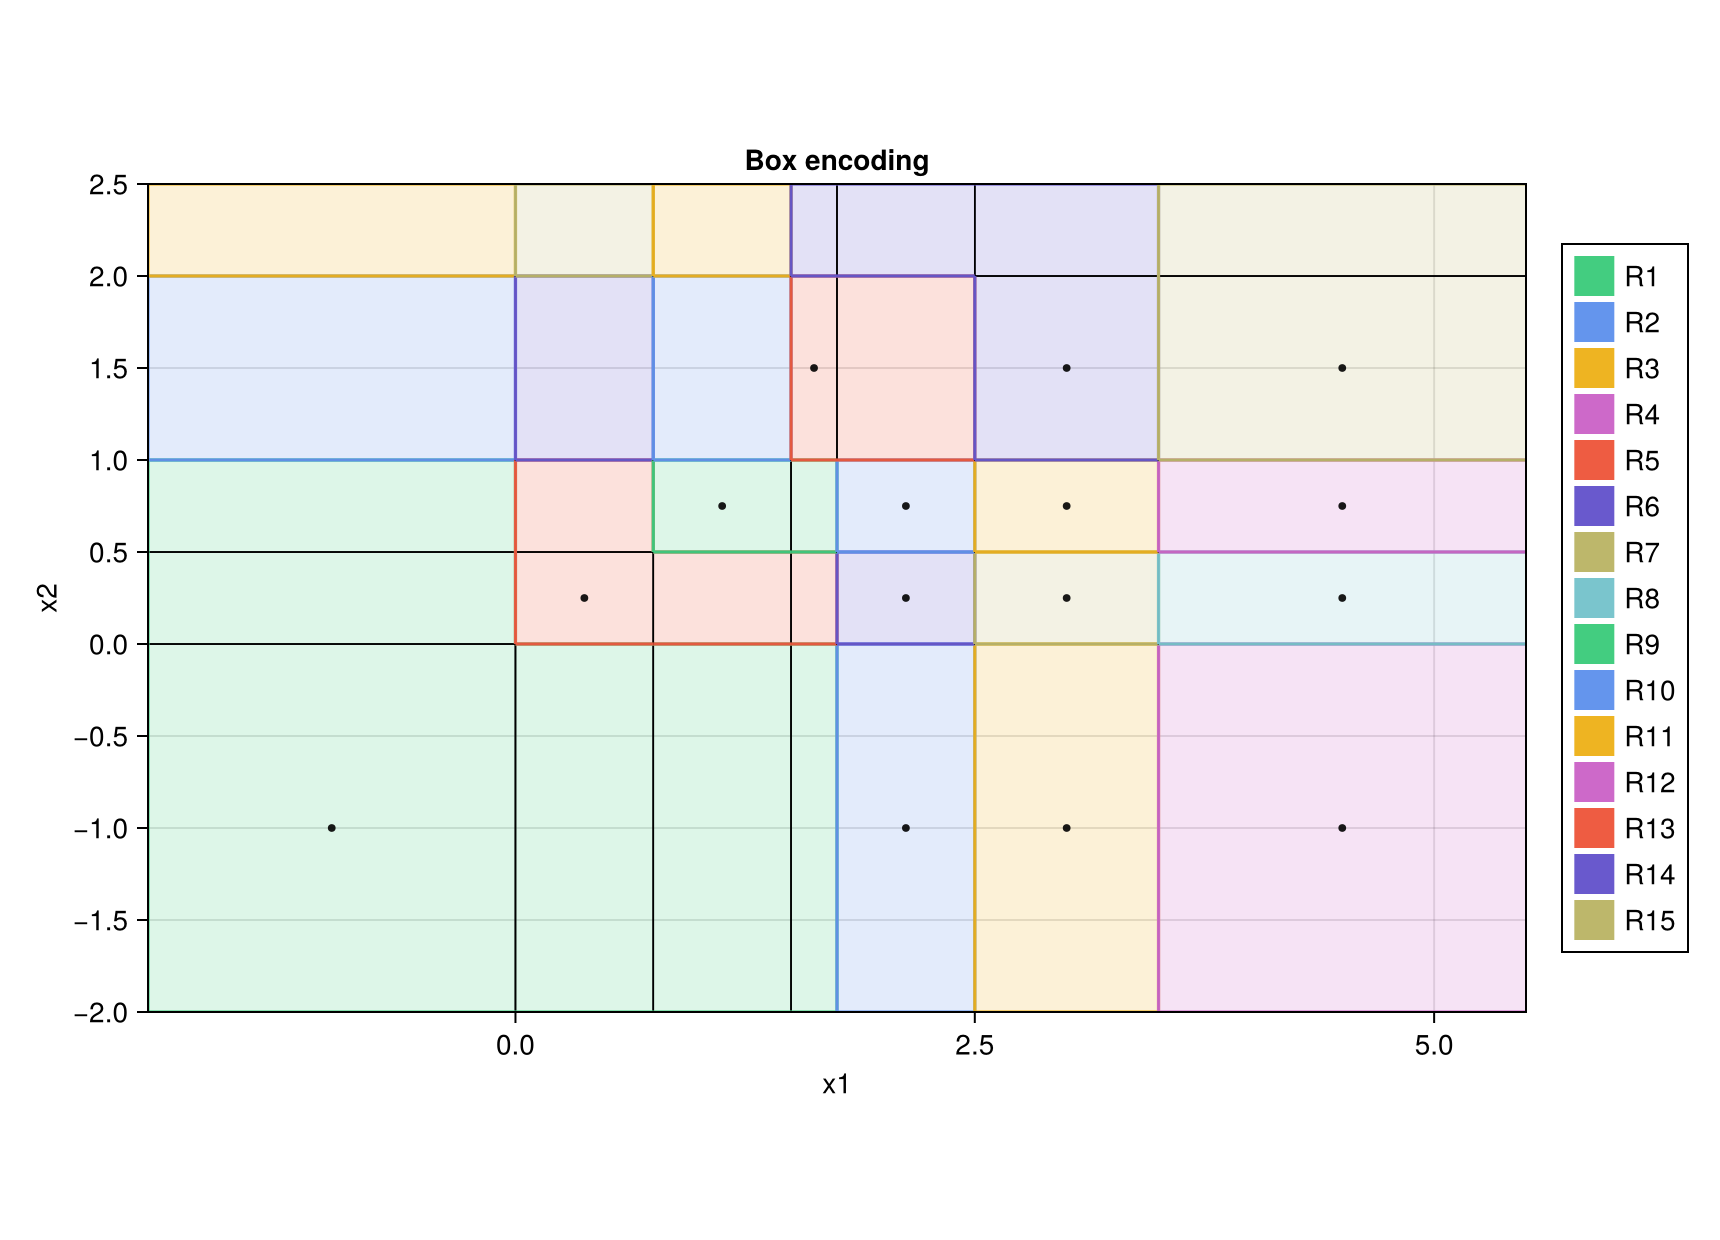

In [8]:
TO.visualize(TO.encoding_map(enc_box_coupled); kind=:regions, backend=:cairomakie)


In [9]:
pi_pl = TO.encoding_map(enc_pl_diag)

(; pl_axes=TO.encoding_axes(pi_pl),
   pl_visuals=TO.available_visuals(pi_pl),
   pl_encoding_summary=TO.describe(enc_pl_diag),
   note="Current PL compiled encoding does not register a direct public :regions view; use summaries here.")


(pl_axes = nothing, pl_visuals = (), pl_encoding_summary = (kind = :encoding_result, poset_type = TamerOp.ZnEncoding.SignaturePoset{1, 1}, module_type = TamerOp.Modules.PModule{Rational{BigInt}, TamerOp.CoreModules.CoeffFields.QQField, Matrix{Rational{BigInt}}, TamerOp.ZnEncoding.SignaturePoset{1, 1}}, encoding_map_type = TamerOp.EncodingCore.CompiledEncoding{TamerOp.PLPolyhedra.PLEncodingMap, TamerOp.ZnEncoding.SignaturePoset{1, 1}, Nothing, Vector{Tuple}, TamerOp.CoreModules.EncodingCache}, compiled = true, backend = :pl, has_cohomology = true, has_presentation = true, module_dims = [0, 1, 2, 0, 0, 1, 0, 0, 0]), note = "Current PL compiled encoding does not register a direct public :regions view; use summaries here.")

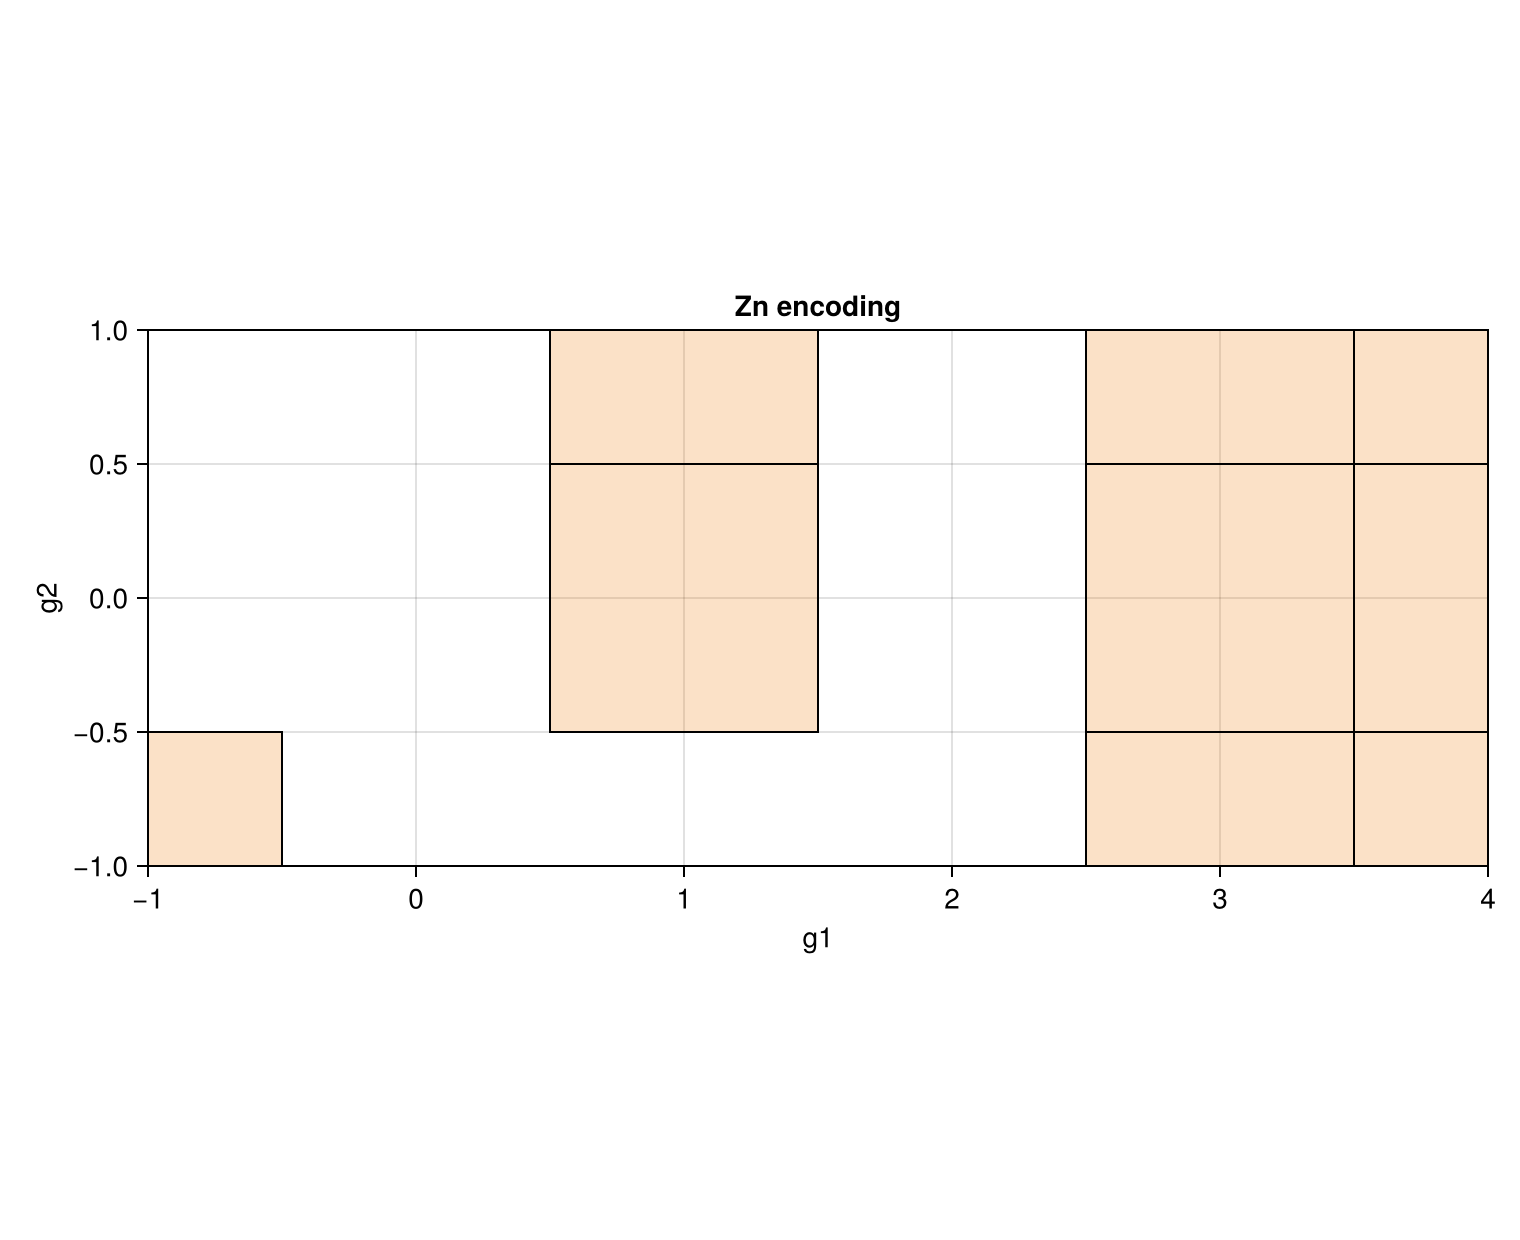

In [10]:
TO.visualize(TO.encoding_map(enc_flange_rect); kind=:regions, backend=:cairomakie)


## 4. Inspect the encoded geometry and one invariant

At this point the source families have done their job. The encoded object is now the stable computational handle.

We use `enc_box_coupled` for the invariant step because the coupled staircase source usually gives a richer rank pattern than the simpler diagonal examples. The rank values are still discrete integers on encoded regions, but this example makes the region/rank structure easier to see.


In [11]:
rank_coupled = TO.rank_invariant(enc_box_coupled)


RankInvariantResult
  nentries: 10
  nnonzero: 10
  store_zeros: false
  nvertices: 15
  poset_type: TamerOp.ZnEncoding.SignaturePoset{1, 1}

First inspect the coupled rank object and one representative encoding map through cheap summaries.

- `describe(rank_coupled)` tells us what invariant object we built.
- `encoding_axes(...)` reminds us where the region coordinates live.
- `available_visuals(rank_coupled)` tells us what rank-side views can be requested next.


In [12]:
(; box_axes=TO.encoding_axes(TO.encoding_map(enc_box_diag)),
   coupled_rank_summary=TO.describe(rank_coupled),
   coupled_rank_visuals=TO.available_visuals(rank_coupled))


(box_axes = ([0.0, 1.0, 1.5, 2.5], [0.0, 0.25, 1.0, 1.25]), coupled_rank_summary = (kind = :rank_invariant, nentries = 10, nnonzero = 10, store_zeros = false, nvertices = 15, poset_type = TamerOp.ZnEncoding.SignaturePoset{1, 1}), coupled_rank_visuals = (:rank_heatmap, :rank_rectangles))

Now build the visual specs explicitly.

- `kind=:regions` summarizes the encoded region geometry of `enc_box_diag`.
- `kind=:rank_heatmap` is a compact visual summary of the coupled rank invariant.

The important workflow idea is the same as in notebook 00: `visual_spec(...)` builds the plan, and `visual_summary(...)` gives a cheap notebook-side summary of that plan.


In [13]:
box_regions_spec = TO.Visualization.visual_spec(TO.encoding_map(enc_box_diag); kind=:regions)
coupled_rank_spec = TO.Visualization.visual_spec(rank_coupled; kind=:rank_heatmap)

(; box_regions_summary=TO.Visualization.visual_summary(box_regions_spec),
   coupled_rank_heatmap_summary=TO.Visualization.visual_summary(coupled_rank_spec))


(box_regions_summary = (kind = :visualization_spec, visual_kind = :regions, title = "Box encoding", subtitle = "", nlayers = 17, npanels = 0, layer_types = (:RectLayer, :SegmentLayer, :RectLayer, :SegmentLayer, :RectLayer, :SegmentLayer, :RectLayer, :SegmentLayer, :RectLayer, :SegmentLayer, :RectLayer, :SegmentLayer, :RectLayer, :SegmentLayer, :RectLayer, :SegmentLayer, :PointLayer), axes = (xlabel = "x1", ylabel = "x2", xlimits = (-2.0, 4.5), ylimits = (-2.0, 1.625), zlabel = "z", zlimits = nothing, aspect = :data, xticks = nothing, yticks = nothing), metadata = (object = :pl_boxes, nregions = 8, ncells = 25, query_count = 0, figure_size = (860, 620), legend_position = :right), legend_visible = true, interaction = (hover = true, labels = false, clicks = false, widgets = (), notebook = :summary_card)), coupled_rank_heatmap_summary = (kind = :visualization_spec, visual_kind = :rank_heatmap, title = "Rank invariant heatmap", subtitle = "rank values on comparable poset pairs", nlayers = 1

Now render every visualization that the coupled rank object says it supports.

This is the notebook pattern to remember:

- ask the object what views it has with `available_visuals(...)`,
- then render those views explicitly.

For teaching, `:rank_rectangles` is usually the most literal view because rank values are discrete and piecewise constant. The heatmap is a compact overview, not a claim of smooth variation.


In [14]:
coupled_rank_visual_kinds = TO.available_visuals(rank_coupled)

for kind in coupled_rank_visual_kinds
    println("visualizing kind = ", kind)
    try
        display(TO.visualize(rank_coupled; kind=kind))
    catch err
        display((; kind,
                  visualization_error=sprint(showerror, err),
                  note="If no renderer is active, use the visual summaries above or the export cell below."))
    end
end


visualizing kind = rank_heatmap
visualizing kind = rank_rectangles


(kind = :rank_heatmap, visualization_error = "MethodError: no method matching WGLMakie.ScreenConfig(::Float64, ::Nothing, ::Makie.Automatic, ::Makie.Automatic, ::Nothing, ::Bool)\nThe type `WGLMakie.ScreenConfig` exists, but no method is defined for this combination of argument types when trying to construct it.\n\nClosest candidates are:\n  WGLMakie.ScreenConfig(::Number, ::Any, ::Union{Nothing, Makie.Automatic, Number}, ::Union{Nothing, Makie.Automatic, Number}, ::Union{Nothing, Bool}, ::Bool) (method too new to be called from this world context.)\n   @ WGLMakie ~/.julia/packages/WGLMakie/6mizW/src/display.jl:16\n", note = "If no renderer is active, use the visual summaries above or the export cell below.")

(kind = :rank_rectangles, visualization_error = "MethodError: no method matching WGLMakie.ScreenConfig(::Float64, ::Nothing, ::Makie.Automatic, ::Makie.Automatic, ::Nothing, ::Bool)\nThe type `WGLMakie.ScreenConfig` exists, but no method is defined for this combination of argument types when trying to construct it.\n\nClosest candidates are:\n  WGLMakie.ScreenConfig(::Number, ::Any, ::Union{Nothing, Makie.Automatic, Number}, ::Union{Nothing, Makie.Automatic, Number}, ::Union{Nothing, Bool}, ::Bool) (method too new to be called from this world context.)\n   @ WGLMakie ~/.julia/packages/WGLMakie/6mizW/src/display.jl:16\n", note = "If no renderer is active, use the visual summaries above or the export cell below.")

## 5. Export two visuals to disk

This is the canonical export path. `save_visuals(...)` takes an output directory plus one request per logical figure.

Each request uses a `stem`, which is just the basename without a directory or extension. The returned paths tell us which concrete files were actually written.


In [15]:
outdir = joinpath(_TO_ROOT, "examples", "_outputs", "combinatorial_cowork_2026", NOTEBOOK_STEM)
mkpath(outdir)

exports = TO.save_visuals(
    outdir,
    [
        (; stem="box_diag_regions", obj=TO.encoding_map(enc_box_diag), kind=:regions),
        (; stem="box_coupled_rank_heatmap", obj=rank_coupled, kind=:rank_heatmap),
    ];
    format=:html,
    backend=:cairomakie,
)

Dict(TO.export_stem(r) => TO.export_path(r) for r in exports)


Dict{String, String} with 2 entries:
  "box_coupled_rank_heatmap" => "/home/eriknovak/Documents/duke_fall_2025/tamer…
  "box_diag_regions"         => "/home/eriknovak/Documents/duke_fall_2025/tamer…

## Try this next

Change one source object and rerun the same workflow.

Good next edits:
- replace `box_diag` with a different `staircase_box_fringe(...)`,
- or change the `bars=` data for `pl_diag`.

Then rerun the encoding, summary, and visual cells and compare what changes at the source level versus what stays stable at the workflow level.


In [16]:
box_variant = SD.box_bar_fringe(
    bars=[([0.0, 0.0], [1.25, 1.0]), ([1.0, 0.0], [2.5, 1.75])]
)
enc_variant = TO.encode(box_variant)

(; variant_source=TO.describe(box_variant),
   variant_encoding=TO.describe(enc_variant),
   variant_visuals=TO.available_visuals(TO.encoding_map(enc_variant)))


(variant_source = (kind = :synthetic_box_fringe, ambient_dim = 2, nupsets = 2, ndownsets = 2, matrix_size = (2, 2), field = TamerOp.CoreModules.CoeffFields.QQField()), variant_encoding = (kind = :encoding_result, poset_type = TamerOp.ZnEncoding.SignaturePoset{1, 1}, module_type = TamerOp.Modules.PModule{Rational{BigInt}, TamerOp.CoreModules.CoeffFields.QQField, Matrix{Rational{BigInt}}, TamerOp.ZnEncoding.SignaturePoset{1, 1}}, encoding_map_type = TamerOp.EncodingCore.CompiledEncoding{TamerOp.PLBackend.PLEncodingMapBoxes{2, 1, 1}, TamerOp.ZnEncoding.SignaturePoset{1, 1}, Tuple{Vector{Float64}, Vector{Float64}}, Vector{Tuple{Float64, Float64}}, TamerOp.CoreModules.EncodingCache}, compiled = true, backend = :pl_backend, has_cohomology = true, has_presentation = true, module_dims = [0, 0, 0, 1, 2, 1, 0, 0, 0]), variant_visuals = (:regions, :region_labels, :query_overlay))